<a href="https://colab.research.google.com/github/Orzilber/computationl-statistics/blob/collab/Gradient_Descent_Examples.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

                       STEP-BY-STEP CONVERGENCE MONITOR                       
Step    | Unscaled Loss | Unscaled Beta Vector | Scaled Loss | Transformed Scaled Beta
------------------------------------------------------------------------------
1       | 1490.0553     | [0.00, 0.00, 0.00] | 1490.0553   | [0.00, 0.00, 0.00]  
10      | 164.9007      | [0.00, -0.00, 0.34] | 216.0070    | [5.49, -2.47, 0.30] 
100     | 6.2861        | [0.00, -0.00, 0.50] | 0.0946      | [1.91, -3.02, 0.50] 
1000    | 6.1785        | [0.02, -0.03, 0.50] | 0.0946      | [1.91, -3.02, 0.50] 
10000   | 5.2002        | [0.18, -0.28, 0.50] | 0.0946      | [1.91, -3.02, 0.50] 
50000   | 2.4369        | [0.74, -1.16, 0.50] | 0.0946      | [1.91, -3.02, 0.50] 
100000  | 0.9790        | [1.19, -1.88, 0.50] | 0.0946      | [1.91, -3.02, 0.50] 
500000  | 0.0950        | [1.89, -2.99, 0.50] | 0.0946      | [1.91, -3.02, 0.50] 
True Target Beta Vector: [2.0, -3.0, 0.5]

## Equivalence Verification
---------------------

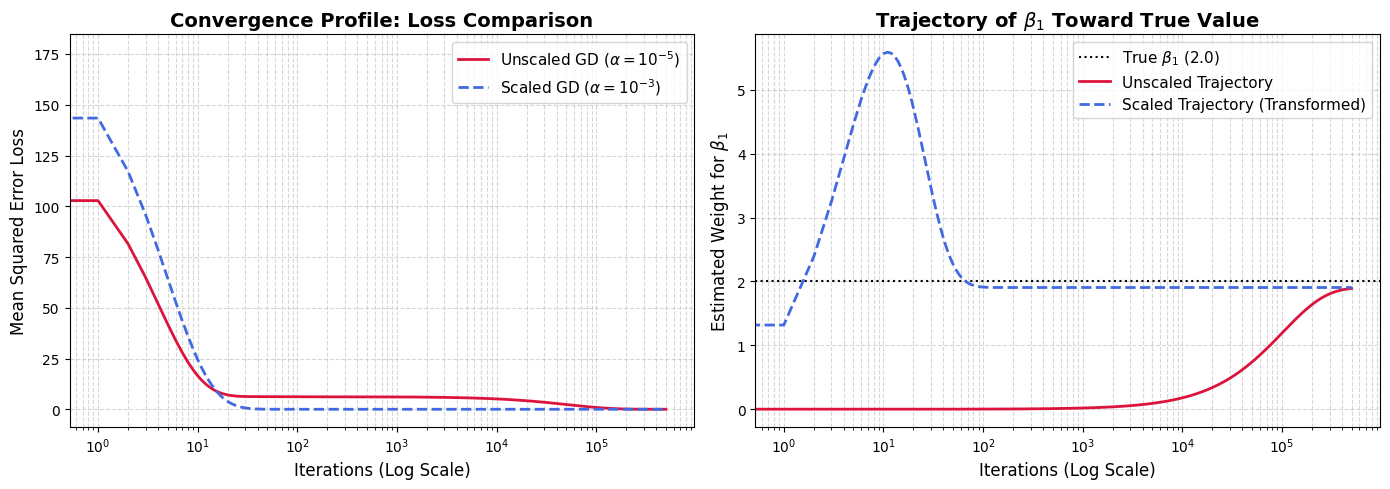

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# 1. Generate Toy Data
n = 100
x1 = np.random.normal(0, 1, (n, 1))
x2 = np.random.normal(0, 1, (n, 1))
x3 = np.random.normal(0, 100, (n, 1))  # Large scale feature

X_unscaled = np.hstack([x1, x2, x3])
beta_true_unscaled = np.array([[2.0], [-3.0], [0.5]])
y = X_unscaled @ beta_true_unscaled + np.random.normal(0, 0.5, (n, 1))

# 2. Compute Scaling Diagonal Matrix S
# S_ii = n / ||x_i||_2
col_norms = np.linalg.norm(X_unscaled, axis=0)
S_diag = n / col_norms
S = np.diag(S_diag)
X_scaled = X_unscaled @ S

# 3. GD Helper Functions
def compute_loss(X, y, beta):
    return (1 / (2 * n)) * np.sum((X @ beta - y) ** 2)

def compute_gradient(X, y, beta):
    return (1 / n) * X.T @ (X @ beta - y)

def run_gradient_descent_with_logging(X, y, learning_rate, steps, print_steps):
    beta = np.zeros((X.shape[1], 1))
    loss_history = []
    beta_history = []
    log_data = {}

    for step in range(1, steps + 1):
        # Record state before the gradient step
        current_loss = compute_loss(X, y, beta)
        loss_history.append(current_loss)
        beta_history.append(beta.copy())

        if step in print_steps:
            log_data[step] = {
                'loss': current_loss,
                'beta': beta.copy()
            }

        # Optimization step
        grad = compute_gradient(X, y, beta)
        beta = beta - learning_rate * grad

    return beta, np.array(loss_history), np.array(beta_history), log_data

# 4. Optimization Settings
steps_to_print = [1, 10, 100, 1000, 10000, 50000, 100000, 500000]
max_steps = 500000

lr_unscaled = 1e-5
lr_scaled = 1e-3

# Run optimizations
beta_unscaled_f, loss_unscaled, betas_unscaled, logs_unscaled = run_gradient_descent_with_logging(
    X_unscaled, y, lr_unscaled, max_steps, steps_to_print
)
beta_scaled_f, loss_scaled, betas_scaled, logs_scaled = run_gradient_descent_with_logging(
    X_scaled, y, lr_scaled, max_steps, steps_to_print
)

# 5. Live Summary Printing per Selected Step
print(f"{'STEP-BY-STEP CONVERGENCE MONITOR':^78}")
print("=" * 78)
print(f"{'Step':<7} | {'Unscaled Loss':<13} | {'Unscaled Beta Vector':<16} | {'Scaled Loss':<11} | {'Transformed Scaled Beta':<20}")
print("-" * 78)

for step in steps_to_print:
    u_loss = logs_unscaled[step]['loss']
    u_beta = logs_unscaled[step]['beta'].flatten()

    s_loss = logs_scaled[step]['loss']
    s_beta = logs_scaled[step]['beta']
    # Map back to unscaled space for live tracking: beta_unscaled = S @ beta_scaled
    s_beta_transformed = (S @ s_beta).flatten()

    u_beta_str = f"[{u_beta[0]:.2f}, {u_beta[1]:.2f}, {u_beta[2]:.2f}]"
    s_beta_str = f"[{s_beta_transformed[0]:.2f}, {s_beta_transformed[1]:.2f}, {s_beta_transformed[2]:.2f}]"

    print(f"{step:<7} | {u_loss:<13.4f} | {u_beta_str:<16} | {s_loss:<11.4f} | {s_beta_str:<20}")

print("=" * 78)
print(f"True Target Beta Vector: [{beta_true_unscaled[0][0]}, {beta_true_unscaled[1][0]}, {beta_true_unscaled[2][0]}]\n")

# 6. Final Estimator Verification
print("## Equivalence Verification")
print("-" * 30)
beta_scaled_transformed_final = S @ beta_scaled_f
print("Final Beta (Unscaled GD):\n", np.round(beta_unscaled_f, 4).flatten())
print("Transformed Final Beta (S @ Beta_scaled):\n", np.round(beta_scaled_transformed_final, 4).flatten())
print(f"Are they equivalent? {np.allclose(beta_unscaled_f, beta_scaled_transformed_final, rtol=1e-3)}")

# 7. Generate Plots
betas_scaled_transformed_all = np.array([S @ b for b in betas_scaled])

plt.figure(figsize=(14, 5))

# Plot 1: Loss Convergence
plt.subplot(1, 2, 1)
plt.plot(loss_unscaled[10:], label='Unscaled GD ($\\alpha=10^{-5}$)', color='crimson', linewidth=2)
plt.plot(loss_scaled[10:], label='Scaled GD ($\\alpha=10^{-3}$)', color='royalblue', linewidth=2, linestyle='--')
plt.xscale('log')
plt.xlabel('Iterations (Log Scale)', fontsize=12)
plt.ylabel('Mean Squared Error Loss', fontsize=12)
plt.title('Convergence Profile: Loss Comparison', fontsize=14, fontweight='bold')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=11)

# Plot 2: Trajectory mapping for Feature 1 (beta_1)
plt.subplot(1, 2, 2)
plt.axhline(y=beta_true_unscaled[0][0], color='black', linestyle=':', label='True $\\beta_1$ (2.0)')
plt.plot(betas_unscaled[:, 0, 0], label='Unscaled Trajectory', color='crimson', linewidth=2)
plt.plot(betas_scaled_transformed_all[:, 0, 0], label='Scaled Trajectory (Transformed)', color='royalblue', linewidth=2, linestyle='--')
plt.xscale('log')
plt.xlabel('Iterations (Log Scale)', fontsize=12)
plt.ylabel('Estimated Weight for $\\beta_1$', fontsize=12)
plt.title('Trajectory of $\\beta_1$ Toward True Value', fontsize=14, fontweight='bold')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()